In [1]:
import pandas as pd

# Load dataset
df = pd.read_excel("Spam Email Detection.xlsx")

print("Dataset Shape:", df.shape)
print("\nDataset Head:")
print(df.head())

Dataset Shape: (5572, 5)

Dataset Head:
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [2]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [4]:
# Data Cleaning
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [5]:
df = df.dropna()

In [13]:
print(df.columns)

Index(['label', 'message'], dtype='object')


In [9]:
df.columns = ['label', 'message']

In [14]:
X = df['message']
y = df['label']

In [15]:
import pandas as pd

df = pd.read_excel("Spam Email Detection.xlsx")

print("Original Columns:", df.columns)

df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']
df.loc[:, 'label'] = df['label'].map({'ham': 0, 'spam': 1})

print("Cleaned Columns:", df.columns)
print(df.head())

Original Columns: Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')
Cleaned Columns: Index(['label', 'message'], dtype='object')
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


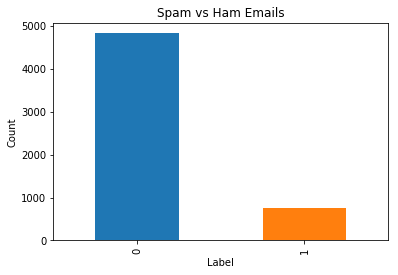

In [18]:
#Spam vs Ham Count 
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Spam vs Ham Emails")
plt.show()

In [20]:
# Remove missing messages
df = df.dropna(subset=['message'])

# Convert all messages to string
df['message'] = df['message'].astype(str)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['message']
y = df['label']

vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X_vectorized = vectorizer.fit_transform(X)

In [22]:
# Text Preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['message']
y = df['label']

vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X_vectorized = vectorizer.fit_transform(X)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

In [24]:
# Model Training
# Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9811659192825112
             precision    recall  f1-score   support

          0       0.98      1.00      0.99       965
          1       1.00      0.86      0.92       150

avg / total       0.98      0.98      0.98      1115



In [25]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9560538116591928
             precision    recall  f1-score   support

          0       0.95      1.00      0.98       965
          1       0.97      0.69      0.81       150

avg / total       0.96      0.96      0.95      1115



In [26]:
# SVC
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.97847533632287
             precision    recall  f1-score   support

          0       0.98      1.00      0.99       965
          1       0.98      0.86      0.91       150

avg / total       0.98      0.98      0.98      1115



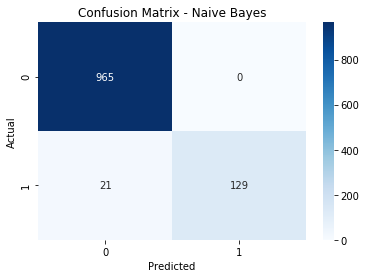

In [27]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [30]:
#Email Testing System
def predict_email(email_text):
    email_vector = vectorizer.transform([email_text])
    prediction = nb.predict(email_vector)
    
    if prediction[0] == 1:
        return "Spam Email"
    else:
        return "Not Spam (Ham)"

print(predict_email("Congratulations! You won a free iPhone. Click now"))
print(predict_email("Hello, can we meet tomorrow for project discussion?"))

Spam Email
Not Spam (Ham)
